# CUAD: exploring the data

The [Contract Understanding Atticus Dataset](https://www.atticusprojectai.org/cuad) is 510
commercial contracts annotated by lawyers for 41 clause categories, framed as SQuAD 2.0
extractive QA: *find the span, or abstain*.

This notebook flattens the nested JSON into three tidy tables and then works through the four
things that actually shape the task:

| # | Question | Section |
|---|---|---|
| 1 | How often is each clause present? | [Rarity](#1-rarity) |
| 2 | When present, how many spans? | [Burstiness](#2-burstiness) |
| 3 | Where in the document does it live? | [Position](#3-position) |
| 4 | Can the test split even measure it? | [Measurability](#4-measurability) |

Then a highlighter for reading annotations in context.

**Requires** `pandas`, `matplotlib`. Run the cell below to check.

In [6]:
# pip install pandas
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 50.8 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 57.8 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pil

In [1]:
import sys, json, re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML, display

DATA = Path('data')
assert DATA.exists(), f'run this notebook from the cuad/ directory (cwd={Path.cwd()})'
print('pandas', pd.__version__, '| matplotlib', mpl.__version__)

pandas 3.0.5 | matplotlib 3.11.2


In [2]:
df = pd.read_json(DATA / 'cuad-v1.0.jsonl', lines=True)

FileNotFoundError: File data\cuad-v1.0.jsonl does not exist

## Plot style

One accent blue for single-series charts, a single-hue ramp for magnitude, and recessive
hairline axes. Setting it once here keeps every figure below consistent.

In [ ]:
BLUE, RED, AMBER = '#2a78d6', '#d03b3b', '#b07800'
INK, MUTED, GRID = '#0b0b0b', '#898781', '#e1e0d9'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'figure.facecolor': 'white',
    'font.size': 9, 'font.family': 'sans-serif',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelcolor': INK, 'ytick.labelcolor': INK,
    'legend.frameon': False,
})

def tidy(ax, xgrid=False):
    """Hairline grid on one axis only, no box around the plot."""
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.grid(axis='x' if xgrid else 'y')
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

## Loading

The files are SQuAD-shaped: `data -> paragraphs -> qas -> answers`. Each contract is one entry
with exactly one paragraph holding the whole contract text.

The category name is recoverable from the question id, which looks like
`<CONTRACT TITLE>__<Category>`. In the training file it carries an extra `_0`/`_1` suffix,
because a question with N gold spans is **split into N separate entries** there - the HF SQuAD
pipeline can only train on one start/end target per example. `test.json` keeps them merged.

Three tables come out: one row per contract, one per question, one per annotated span.

In [9]:
QPREFIX = re.compile(r'^Highlight the parts \(if any\) of this contract related to "(.*?)"')

def category_of(qa):
    """Category for a qa entry. Prefer the id suffix, fall back to the question text."""
    qid = qa.get('id', '')
    if '__' in qid:
        tail = qid.rsplit('__', 1)[1]
        return re.sub(r'_\d+$', '', tail)   # strip the train-file _0/_1 suffix
    m = QPREFIX.match(qa.get('question', ''))
    return m.group(1) if m else 'Unknown'

def load(path, split):
    doc = json.loads(Path(path).read_text(encoding='utf-8'))
    docs, qas, spans = [], [], []
    for entry in doc['data']:
        title = entry.get('title', '(untitled)')
        for para in entry['paragraphs']:
            ctx = para['context']
            docs.append(dict(title=title, split=split, n_chars=len(ctx),
                             n_questions=len(para['qas'])))
            for qa in para['qas']:
                cat = category_of(qa)
                answers = qa.get('answers') or []
                found = bool(answers) and not qa.get('is_impossible', False)
                qas.append(dict(title=title, split=split, category=cat, found=found,
                                n_spans=len(answers) if found else 0,
                                question=qa.get('question', '')))
                if found:
                    for a in answers:
                        spans.append(dict(title=title, split=split, category=cat,
                                          start=a['answer_start'], length=len(a['text']),
                                          rel_pos=a['answer_start'] / max(1, len(ctx)),
                                          text=a['text']))
    return (pd.DataFrame(docs), pd.DataFrame(qas), pd.DataFrame(spans))

docs, qas, spans = load(DATA / 'CUADv1.json', 'all')
print(f'{len(docs):,} contracts | {len(qas):,} questions | {len(spans):,} spans')
docs.head(3)

510 contracts | 20,910 questions | 13,823 spans


,title,split,n_chars,n_questions
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,all,54290,41
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",all,70383,41
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,all,11475,41


### Category metadata

`category_descriptions.csv` carries the lawyer-written description, the expected answer format,
and a `Group` label. It spells names in mixed case (`Cap on Liability`) while the question ids
are title-cased (`Cap On Liability`) - joining on `.title()` is what `evaluate.py` does too.

In [10]:
cat_meta = pd.read_csv('../category_descriptions.csv', encoding='utf-8-sig')
cat_meta.columns = ['category', 'description', 'answer_format', 'group']
for col, prefix in [('category', 'Category: '), ('description', 'Description: '),
                    ('answer_format', 'Answer Format: '), ('group', 'Group: ')]:
    cat_meta[col] = cat_meta[col].str.split(prefix).str[-1].str.strip()
cat_meta['category'] = cat_meta['category'].str.title()

assert set(cat_meta.category) == set(qas.category), 'category names do not line up'
cat_meta.head(4)

,category,description,answer_format,group
0,Document Name,The name of the contract,Contract Name,-
1,Parties,The two or more parties who signed the contract,Entity or individual names,-
2,Agreement Date,The date of the contract,Date (mm/dd/yyyy),1
3,Effective Date,The date when the contract is effective,Date (mm/dd/yyyy),1


### The summary table

One row per category - this drives most of what follows.

In [5]:
g = qas.groupby('category')
cats = pd.DataFrame({
    'asked':   g.size(),
    'present': g.found.sum(),
    'spans':   g.n_spans.sum(),
}).reset_index()
cats['rate'] = 100 * cats.present / cats.asked            # how common
cats['burst'] = cats.spans / cats.present.clip(lower=1)   # spans when present

sg = spans.groupby('category')
cats = cats.merge(sg.length.median().rename('median_span_chars').reset_index(), on='category')
cats = cats.merge(sg.rel_pos.mean().rename('mean_rel_pos').reset_index(), on='category')
cats = cats.merge(cat_meta[['category', 'group', 'answer_format']], on='category')

cats = cats.sort_values('rate', ascending=False).reset_index(drop=True)
cats.round(2)

,category,asked,present,spans,rate,burst,median_span_chars,mean_rel_pos,group,answer_format
0,Document Name,510,510,521,100.00,1.02,25.0,0.08,-,Contract Name
1,Parties,510,509,2554,99.80,5.02,17.0,0.09,-,Entity or individual names
2,Agreement Date,510,470,476,92.16,1.01,16.0,0.11,1,Date (mm/dd/yyyy)
3,Governing Law,510,437,464,85.69,1.06,178.5,0.78,-,"Name of a US State / non-US Province, Country"
4,Expiration Date,510,413,467,80.98,1.13,195.0,0.41,1,Date (mm/dd/yyyy) / Perpetual
5,Effective Date,510,390,447,76.47,1.15,20.0,0.17,1,Date (mm/dd/yyyy)
6,Anti-Assignment,510,374,654,73.33,1.75,218.5,0.71,3,Yes/No
7,Cap On Liability,510,275,672,53.92,2.44,306.0,0.62,6,Yes/No
8,License Grant,510,255,777,50.00,3.05,356.0,0.33,4,Yes/No
9,Audit Rights,510,214,643,41.96,3.00,253.0,0.47,5,Yes/No


<a id='1-rarity'></a>
## 1. Rarity

The headline property of CUAD: **most clause types are absent from most contracts.** This is
what the paper means by "finding needles in a haystack", and it is why the benchmark is scored
with a precision-recall curve rather than accuracy - a model that abstains on everything would
look fine on naive accuracy.

In [6]:
n_q, n_found = len(qas), int(qas.found.sum())
print(f'{n_found:,} of {n_q:,} questions have an answer  ({100*n_found/n_q:.1f}%)')
print(f'{n_q - n_found:,} are unanswerable            ({100*(n_q-n_found)/n_q:.1f}%)')
print(f'\nmedian category is present in {cats.rate.median():.1f}% of contracts')

6,702 of 20,910 questions have an answer  (32.1%)
14,208 are unanswerable            (67.9%)

median category is present in 23.3% of contracts


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


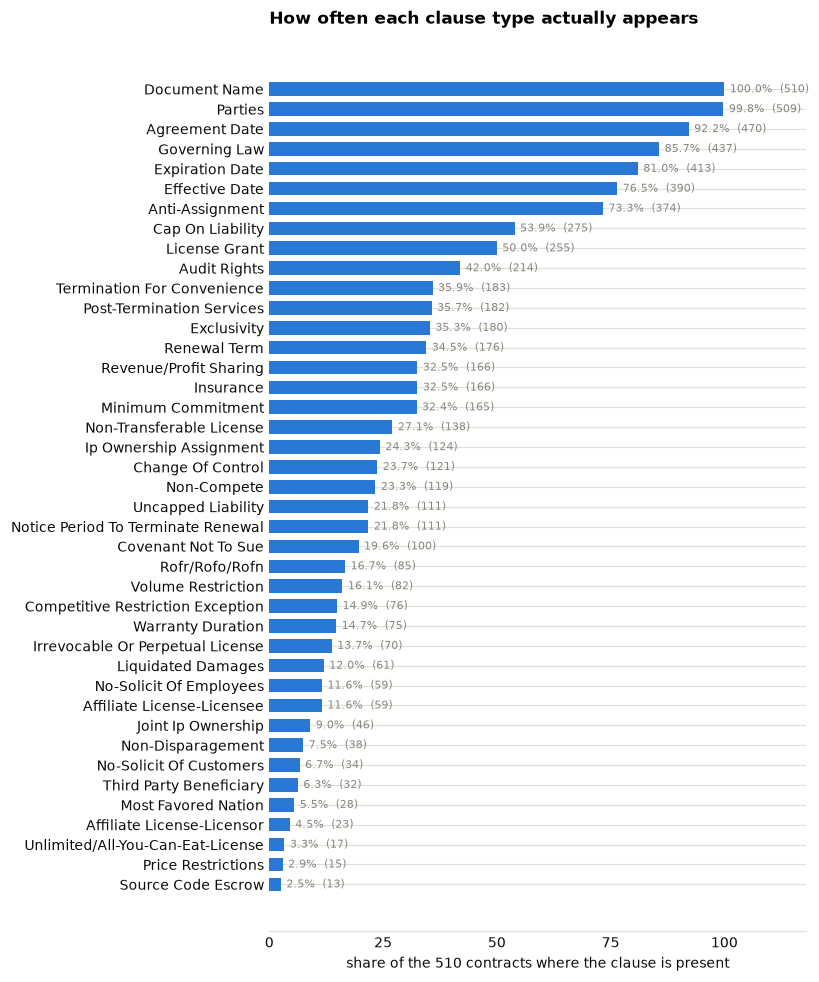

In [7]:
d = cats.sort_values('rate')
fig, ax = plt.subplots(figsize=(7.5, 9))
ax.barh(d.category, d.rate, color=BLUE, height=0.68)
for y, (r, p) in enumerate(zip(d.rate, d.present)):
    ax.text(r + 1.2, y, f'{r:.1f}%  ({p})', va='center', fontsize=7.5, color=MUTED)
ax.set_xlim(0, 118)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('share of the 510 contracts where the clause is present')
ax.set_title('How often each clause type actually appears')
tidy(ax, xgrid=True)
plt.tight_layout(); plt.show()

Six categories are near-universal boilerplate and six sit under 7%. Note what the top of that
chart is: *Document Name*, *Parties*, *Agreement Date*, *Effective Date* are **metadata
extraction**, not clause review. They are present in nearly every contract, so they dominate any
aggregate score - a model can look competent on the benchmark while failing the part that
motivates it.

<a id='2-burstiness'></a>
## 2. Burstiness

How many separate spans get annotated when a clause *is* present. This turns out to be
**independent of rarity**, which is the more interesting result.

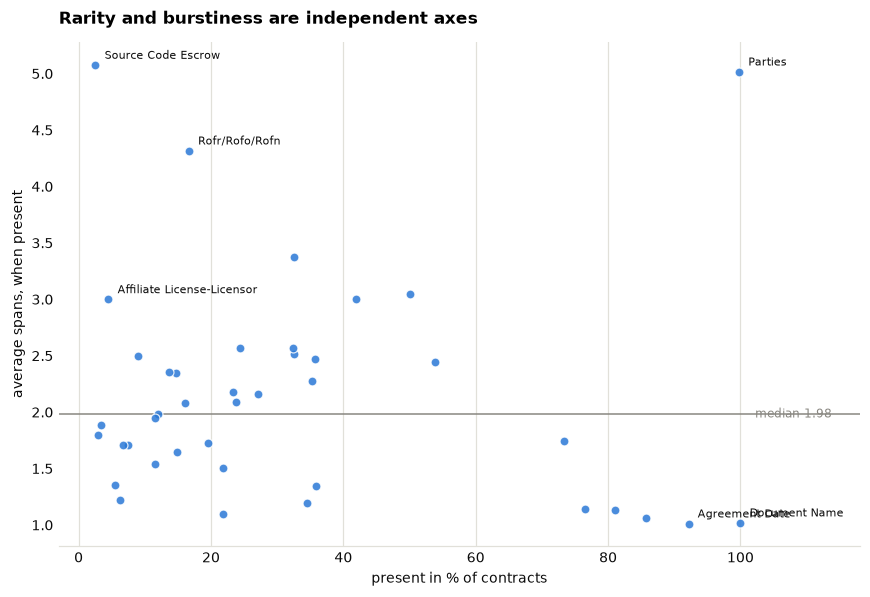

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(cats.rate, cats.burst, s=34, color=BLUE, alpha=.85, zorder=3,
           edgecolor='white', linewidth=.8)
ax.axhline(cats.burst.median(), color=MUTED, lw=1, ls='-', zorder=1)
ax.text(101, cats.burst.median(), f'  median {cats.burst.median():.2f}',
        fontsize=8, color=MUTED, va='center')

# label only the extremes - a name on every point is unreadable
for _, r in cats.iterrows():
    if r.burst > 3.4 or (r.rate > 90 and r.burst < 1.5) or (r.rate < 6 and r.burst > 2):
        ax.annotate(r.category, (r.rate, r.burst), fontsize=7.5, color=INK,
                    xytext=(6, 4), textcoords='offset points')

ax.set_xlabel('present in % of contracts')
ax.set_ylabel('average spans, when present')
ax.set_title('Rarity and burstiness are independent axes')
ax.set_xlim(-3, 118)
tidy(ax)
plt.tight_layout(); plt.show()

In [9]:
cols = ['category', 'rate', 'burst', 'present', 'spans']
print('most bursty:')
display(cats.nlargest(6, 'burst')[cols].round(2))
print('\nrare AND bursty - the hard corner:')
display(cats[(cats.rate < 15)].nlargest(5, 'burst')[cols].round(2))

most bursty:


,category,rate,burst,present,spans
40,Source Code Escrow,2.55,5.08,13,66
1,Parties,99.80,5.02,509,2554
24,Rofr/Rofo/Rofn,16.67,4.32,85,367
14,Insurance,32.55,3.37,166,560
8,License Grant,50.00,3.05,255,777
9,Audit Rights,41.96,3.00,214,643



rare AND bursty - the hard corner:


,category,rate,burst,present,spans
40,Source Code Escrow,2.55,5.08,13,66
37,Affiliate License-Licensor,4.51,3.00,23,69
32,Joint Ip Ownership,9.02,2.50,46,115
28,Irrevocable Or Perpetual License,13.73,2.36,70,165
27,Warranty Duration,14.71,2.35,75,176


*Source Code Escrow* sits in 2.5% of contracts but averages ~5 spans when it appears - the same
burstiness as *Parties*, which is in 99.8%. A model that learns "rare clause, so predict one
span cautiously" is wrong in exactly the place it is hardest to notice.

<a id='3-position'></a>
## 3. Position in the document

Each span has a character offset; dividing by contract length puts every annotation on a 0-1
scale. Binning that into tenths shows whether a clause lives in a predictable part of the
document - a signal a model could lean on, if it were there.

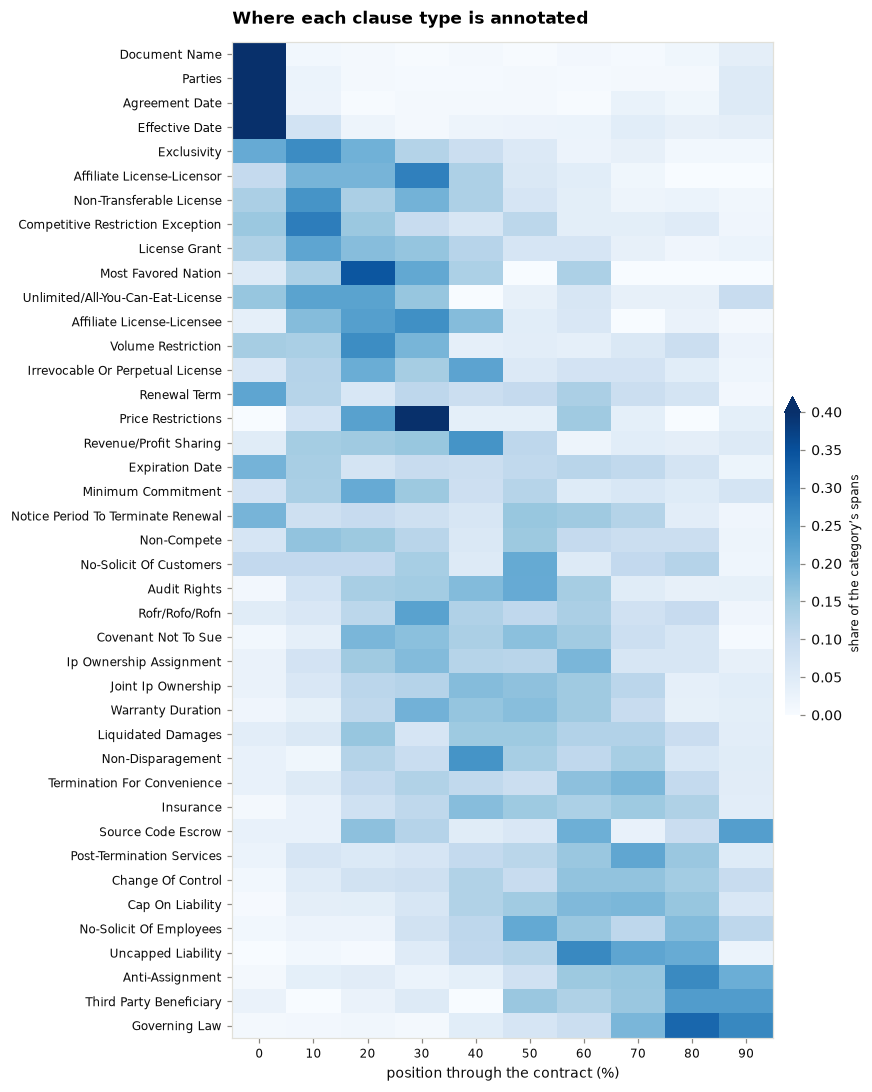

In [10]:
spans['decile'] = (spans.rel_pos * 10).clip(0, 9.999).astype(int)

order = cats.sort_values('mean_rel_pos').category
heat = (spans.pivot_table(index='category', columns='decile', values='start', aggfunc='size')
             .reindex(index=order, columns=range(10)).fillna(0))
heat = heat.div(heat.sum(axis=1), axis=0)   # share of THIS category's spans per tenth

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heat.values, aspect='auto', cmap='Blues', vmin=0, vmax=0.40)
ax.set_yticks(range(len(heat)), heat.index, fontsize=8)
ax.set_xticks(range(10), [f'{i*10}' for i in range(10)], fontsize=8)
ax.set_xlabel('position through the contract (%)')
ax.set_title('Where each clause type is annotated')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=.028, pad=.02, extend='max')
cb.set_label('share of the category\u2019s spans', fontsize=8)
cb.outline.set_visible(False)
plt.tight_layout(); plt.show()

In [11]:
peak = heat.max(axis=1).sort_values(ascending=False)
print('most positionally predictable:')
print(peak.head(5).mul(100).round(1).to_string())
print(f'\nmedian category peaks at only {100*peak.median():.1f}% of its spans in one tenth')
print('(an even scatter would be 10% - so most clause types are barely localised at all)')

most positionally predictable:
category
Document Name         90.0
Parties               88.1
Agreement Date        85.5
Effective Date        71.8
Price Restrictions    40.7

median category peaks at only 21.9% of its spans in one tenth
(an even scatter would be 10% - so most clause types are barely localised at all)


The four metadata categories saturate the first band and nothing else. But the **median**
category peaks around 22% in its best tenth, against 10% for a perfectly even scatter - so for
most clause types, position carries almost no information. The model has to read the whole
contract.

<a id='4-measurability'></a>
## 4. Can the test split measure it?

The 408/102 train/test split is by contract and the two sides do not overlap. But the split is
drawn from the same skewed distribution, so the rarest categories reach the test set with a
handful of examples - or none.

In [12]:
_, qas_tr, _ = load(DATA / 'train_separate_questions.json', 'train')
_, qas_te, spans_te = load(DATA / 'test.json', 'test')

print('contract overlap between splits:',
      len(set(qas_tr.title) & set(qas_te.title)))

cov = (qas_te.groupby('category').found.sum().rename('in_test')
       .reset_index().merge(cats[['category', 'rate', 'present']], on='category')
       .sort_values('in_test'))
cov.head(8)

contract overlap between splits: 0


,category,in_test,rate,present
30,Price Restrictions,0,2.941176,15
34,Source Code Escrow,1,2.549020,13
38,Unlimited/All-You-Can-Eat-License,3,3.333333,17
21,Most Favored Nation,3,5.490196,28
1,Affiliate License-Licensor,6,4.509804,23
36,Third Party Beneficiary,6,6.274510,32
17,Joint Ip Ownership,7,9.019608,46
22,No-Solicit Of Customers,7,6.666667,34


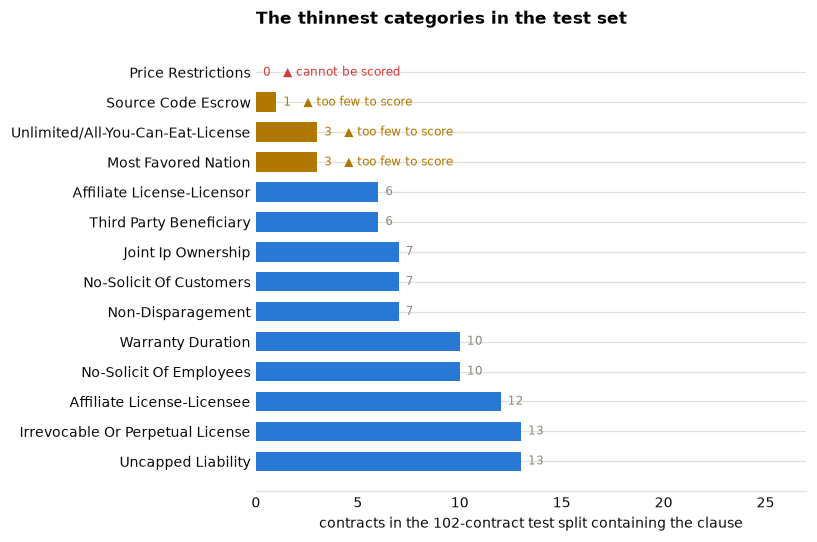

In [13]:
d = cov.head(14).iloc[::-1]
colors = [RED if n == 0 else AMBER if n < 5 else BLUE for n in d.in_test]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(d.category, d.in_test, color=colors, height=.65)
for y, n in enumerate(d.in_test):
    label = 'cannot be scored' if n == 0 else ('too few to score' if n < 5 else '')
    ax.text(n + .35, y, f'{n}' + (f'   \u25b2 {label}' if label else ''),
            va='center', fontsize=8,
            color=RED if n == 0 else AMBER if n < 5 else MUTED)
ax.set_xlim(0, max(d.in_test) + 14)
ax.set_xlabel('contracts in the 102-contract test split containing the clause')
ax.set_title('The thinnest categories in the test set')
tidy(ax, xgrid=True)
plt.tight_layout(); plt.show()

In [14]:
thin = cov[cov.in_test < 5]
print(f'{len(thin)} categories have fewer than 5 test examples:\n')
print(thin[['category', 'in_test', 'present']].to_string(index=False))
print('\nAny per-category score reported for these is noise.')
print('Price Restrictions has zero - all 15 of its contracts landed in train.')

4 categories have fewer than 5 test examples:

                         category  in_test  present
               Price Restrictions        0       15
               Source Code Escrow        1       13
Unlimited/All-You-Can-Eat-License        3       17
              Most Favored Nation        3       28

Any per-category score reported for these is noise.
Price Restrictions has zero - all 15 of its contracts landed in train.


## Span lengths

How much text a single annotation covers. `run.sh` sets `--max_answer_length 512`, so it is
worth knowing how many gold spans that ceiling actually excludes.

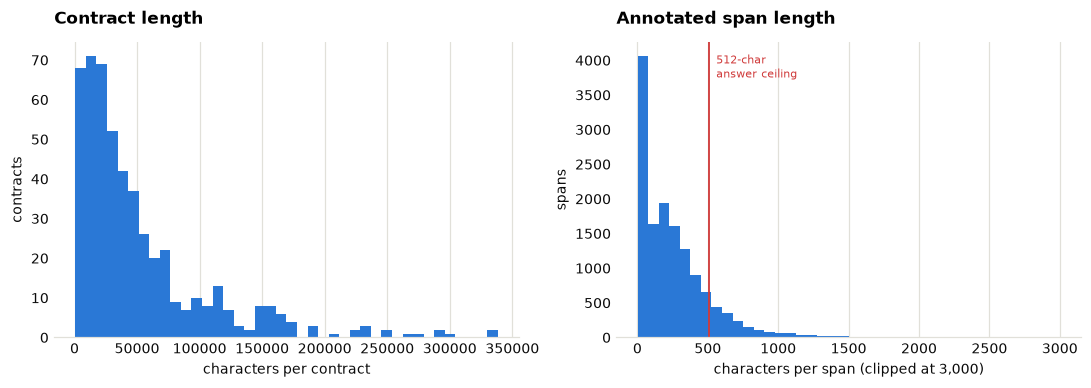

median span 196 chars | 13.4% of gold spans exceed 512 chars
median contract 33,143 chars | longest 338,211


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

ax = axes[0]
ax.hist(docs.n_chars, bins=40, color=BLUE)
ax.set_xlabel('characters per contract'); ax.set_ylabel('contracts')
ax.set_title('Contract length')
tidy(ax)

ax = axes[1]
ax.hist(spans.length.clip(upper=3000), bins=40, color=BLUE)
ax.axvline(512, color=RED, lw=1.2)
ax.text(560, ax.get_ylim()[1]*.88, '512-char\nanswer ceiling', fontsize=7.5, color=RED)
ax.set_xlabel('characters per span (clipped at 3,000)'); ax.set_ylabel('spans')
ax.set_title('Annotated span length')
tidy(ax)

plt.tight_layout(); plt.show()

over = (spans.length > 512).mean()
print(f'median span {spans.length.median():.0f} chars | {100*over:.1f}% of gold spans exceed 512 chars')
print(f'median contract {docs.n_chars.median():,.0f} chars | longest {docs.n_chars.max():,}')

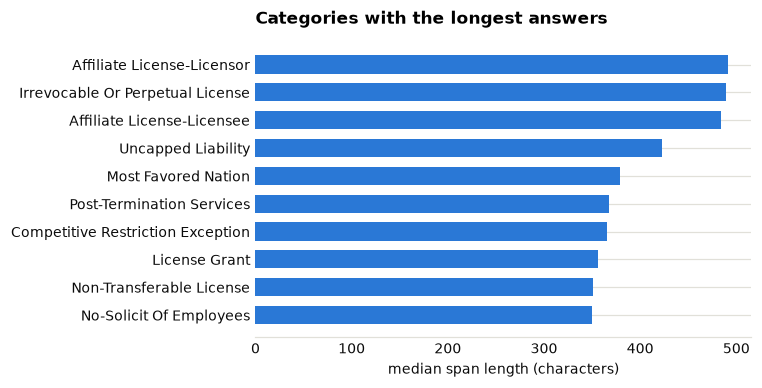

In [16]:
longest = cats.nlargest(10, 'median_span_chars')[['category', 'median_span_chars', 'rate']]
fig, ax = plt.subplots(figsize=(7, 3.6))
d = longest.iloc[::-1]
ax.barh(d.category, d.median_span_chars, color=BLUE, height=.65)
ax.set_xlabel('median span length (characters)')
ax.set_title('Categories with the longest answers')
tidy(ax, xgrid=True)
plt.tight_layout(); plt.show()

## Reading the annotations

Aggregates only go so far - at some point you have to read the clauses. Change `CATEGORY` and
re-run.

In [17]:
CATEGORY = 'Source Code Escrow'   # try: 'Most Favored Nation', 'Non-Compete', 'Governing Law'
N = 6

row = cat_meta[cat_meta.category == CATEGORY].iloc[0]
print(f'{CATEGORY}\n  {row.description}\n  expected format: {row.answer_format}\n')

sel = spans[spans.category == CATEGORY]
print(f'{sel.title.nunique()} contracts, {len(sel)} spans\n' + '-' * 78)
for title, grp in list(sel.groupby('title'))[:N]:
    print(f'\n{title[:76]}')
    for _, s in grp.sort_values('start').iterrows():
        print(f'  [{s.start:>6}] {" ".join(s.text.split())[:210]}')

Source Code Escrow
  Is one party required to deposit its source code into escrow with a third party, which can be released to the counterparty upon the occurrence of certain events (bankruptcy,  insolvency, etc.)?
  expected format: Yes/No

13 contracts, 66 spans
------------------------------------------------------------------------------

CHANGEPOINTCORP_03_08_2000-EX-10.6-LICENSE AND HOSTING AGREEMENT
  [   156] This
  [ 63120] Within sixty (60) days of the Effective Date, Changepoint agrees to execute an escrow agreement by and among Corio, Changepoint and a mutually acceptable escrow agent (the "ESCROW AGENT").
  [ 63336] The Escrow Agent shall require Changepoint to place in an escrow account in Toronto a copy of the source code of the Software including all Updates and Upgrades thereto, documentation and similar materials (the
  [ 63704] Corio shall bear all fees, expenses and other charges to open and maintain such escrow account.
  [ 63818] If a Release Condition (as defined

### Highlighter

The same thing in context: one contract with every annotated span marked. Hover a highlight to
see which category it belongs to. This is the view that makes the sparsity concrete - scroll
through and see how little of the document is marked.

In [18]:
def highlight(title_contains, path=DATA / 'CUADv1.json', max_chars=60000):
    doc = json.loads(Path(path).read_text(encoding='utf-8'))
    entry = next((e for e in doc['data'] if title_contains.lower() in e.get('title', '').lower()), None)
    if entry is None:
        return HTML(f'<p>no contract matching <code>{title_contains}</code></p>')

    para = entry['paragraphs'][0]
    ctx = para['context']
    marks = sorted(({'s': a['answer_start'], 'e': a['answer_start'] + len(a['text']),
                     'c': category_of(qa)}
                    for qa in para['qas'] for a in (qa.get('answers') or [])),
                   key=lambda m: m['s'])

    esc = lambda s: s.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    out, cur = [], 0
    for m in marks:
        if m['s'] < cur:          # skip spans that overlap one already drawn
            continue
        out.append(esc(ctx[cur:m['s']]))
        out.append(f'<mark title="{esc(m["c"])}" style="background:#ffe9a8;'
                   f'border-bottom:2px solid #e0a200">{esc(ctx[m["s"]:m["e"]])}</mark>')
        cur = m['e']
    out.append(esc(ctx[cur:]))
    body = ''.join(out)[:max_chars]

    pct = 100 * sum(m['e'] - m['s'] for m in marks) / len(ctx)
    return HTML(
        f"<p style='font:13px sans-serif'><b>{esc(entry['title'])}</b><br>"
        f"{len(ctx):,} chars &middot; {len(marks)} spans &middot; "
        f"<b>{pct:.1f}%</b> of the document is annotated</p>"
        f"<div style='white-space:pre-wrap;font:12px/1.7 ui-monospace,Consolas,monospace;"
        f"max-height:520px;overflow:auto;border:1px solid #ddd;padding:14px'>{body}</div>")

highlight('DISTRIBUTOR AGREEMENT')

## Export

`cats` is the table behind most of the above - useful to keep beside a model's per-category
results, since it tells you which of those numbers are trustworthy.

In [19]:
out = Path('analysis'); out.mkdir(exist_ok=True)
summary = cats.merge(cov[['category', 'in_test']], on='category')
summary['scoreable'] = np.where(summary.in_test == 0, 'no',
                         np.where(summary.in_test < 5, 'barely', 'yes'))
summary.round(3).to_csv(out / 'category_summary.csv', index=False)
print(f'wrote {out / "category_summary.csv"}  ({len(summary)} rows)')
summary[['category', 'rate', 'burst', 'median_span_chars', 'in_test', 'scoreable']].round(2)

wrote analysis\category_summary.csv  (41 rows)


,category,rate,burst,median_span_chars,in_test,scoreable
0,Document Name,100.00,1.02,25.0,102,yes
1,Parties,99.80,5.02,17.0,102,yes
2,Agreement Date,92.16,1.01,16.0,93,yes
3,Governing Law,85.69,1.06,178.5,83,yes
4,Expiration Date,80.98,1.13,195.0,78,yes
5,Effective Date,76.47,1.15,20.0,70,yes
6,Anti-Assignment,73.33,1.75,218.5,72,yes
7,Cap On Liability,53.92,2.44,306.0,44,yes
8,License Grant,50.00,3.05,356.0,50,yes
9,Audit Rights,41.96,3.00,253.0,38,yes


---

### Where to go next

- **Compare splits.** `load()` takes any of the three files - run the rarity chart against
  `test.json` and against `CUADv1.json` and diff them.
- **Inspect the train file's exploded format.** Its questions carry `_0`/`_1` suffixes;
  `category_of()` strips them, but look at the raw ids to see the transformation.
- **Check what a 512-token window actually holds.** Once `transformers` is installed, tokenize
  a contract and count how many windows at stride 256 contain no gold span at all - that ratio
  is what `get_balanced_dataset()` in `train.py` exists to correct.

Dataset: Hendrycks, Burns, Chen & Ball, *CUAD: An Expert-Annotated NLP Dataset for Legal
Contract Review*, NeurIPS 2021.